# Simple LangGraph Router with Two Specialists

This notebook demonstrates a minimal LangGraph workflow inspired by the main `screening_agent` package, but intentionally stripped down for learning. It uses one router node and two specialist nodes, while allowing each specialist to use its own runtime.

The goal is to stay close to the official LangGraph Graph API examples:

- **State**: a small `TypedDict` with only `question`, `route`, and `answer`;
- **Nodes**: plain Python functions with typed signatures;
- **Edges**: a single `add_conditional_edges(...)` branch from the router to a specialist.

## How this differs from the production-style project

This notebook keeps only the educational core. Compared with `src/screening_agent/`, it intentionally omits:

- persistent checkpoints;
- tools and database lookups;
- Chainlit integration;
- audit events and console streaming;
- subgraphs and retry wrappers.

The notebook now keeps the wiring intentionally simple while allowing separate runtimes:

- the router uses the current `SCREENING_AGENT_CONTROL_*` settings;
- the instructions specialist also uses the control-model settings;
- the symptom specialist uses the current `SCREENING_AGENT_CLINICAL_*` settings, including local GGUF when configured;
- when GGUF is selected, the notebook calls `llama-cpp-python` directly with chat messages instead of using a helper class from `src/`.

No new environment variables are required.

In [1]:
from __future__ import annotations

from collections.abc import Callable
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal, cast
import os

from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field
from typing_extensions import TypedDict


ChatBackendKind = Literal["openai", "openrouter", "openai_compatible"]
ClinicalRuntimeKind = Literal["openai", "openrouter", "openai_compatible", "gguf"]
SpecialistResponder = Callable[[str], str]


@dataclass(frozen=True)
class NotebookChatSettings:
    """Configuration for a chat-model-backed notebook runtime."""

    backend: ChatBackendKind
    model: str
    base_url: str | None
    api_key: str | None
    temperature: float


@dataclass(frozen=True)
class NotebookClinicalSettings:
    """Configuration for the symptom specialist runtime."""

    backend: ClinicalRuntimeKind
    model: str | None
    base_url: str | None
    api_key: str | None
    gguf_model_path: Path | None
    temperature: float


@dataclass(frozen=True)
class NotebookRuntimeSettings:
    """Top-level runtime settings used by the notebook graph."""

    router_model: NotebookChatSettings
    instructions_model: NotebookChatSettings
    symptom_runtime: NotebookClinicalSettings


def _load_env_file(env_path: Path | None = None) -> Path:
    """Load the notebook `.env` file and return its resolved path.

    Args:
        env_path: Optional explicit path to the `.env` file.

    Returns:
        The resolved `.env` path.

    Raises:
        FileNotFoundError: If the `.env` file does not exist.
    """

    resolved_env_path = env_path or Path.cwd() / ".env"
    if not resolved_env_path.exists():
        raise FileNotFoundError(f"Could not find .env file at {resolved_env_path}")
    load_dotenv(resolved_env_path, override=True)
    return resolved_env_path


def _read_chat_backend(value: str) -> ChatBackendKind:
    """Validate a chat backend value.

    Args:
        value: Raw backend value from the environment.

    Returns:
        A validated chat backend literal.

    Raises:
        ValueError: If the backend is not supported.
    """

    normalized_value = value.strip().lower()
    if normalized_value not in {"openai", "openrouter", "openai_compatible"}:
        raise ValueError(
            "Chat backend must be 'openai', 'openrouter', or 'openai_compatible'."
        )
    return cast(ChatBackendKind, normalized_value)


def _read_clinical_backend(value: str) -> ClinicalRuntimeKind:
    """Validate a clinical runtime value.

    Args:
        value: Raw backend value from the environment.

    Returns:
        A validated clinical runtime literal.

    Raises:
        ValueError: If the backend is not supported.
    """

    normalized_value = value.strip().lower()
    if normalized_value not in {"openai", "openrouter", "openai_compatible", "gguf"}:
        raise ValueError(
            "Clinical backend must be 'openai', 'openrouter', 'openai_compatible', or 'gguf'."
        )
    return cast(ClinicalRuntimeKind, normalized_value)


def _read_float_env(name: str, default: float) -> float:
    """Read a floating-point environment variable.

    Args:
        name: Environment variable name.
        default: Default value when the variable is missing.

    Returns:
        The parsed floating-point value.
    """

    raw_value = os.getenv(name)
    if raw_value is None or not raw_value.strip():
        return default
    return float(raw_value)


def load_notebook_runtime_settings(env_path: Path | None = None) -> NotebookRuntimeSettings:
    """Load all notebook runtimes from the current `.env` file.

    Args:
        env_path: Optional explicit path to the `.env` file.

    Returns:
        The runtime settings used by the router and both specialists.

    Raises:
        ValueError: If required model configuration is missing.
    """

    _load_env_file(env_path)

    control_model_name = os.getenv("SCREENING_AGENT_CONTROL_MODEL", "").strip()
    if not control_model_name:
        raise ValueError("SCREENING_AGENT_CONTROL_MODEL must be set in the .env file.")

    control_settings = NotebookChatSettings(
        backend=_read_chat_backend(
            os.getenv("SCREENING_AGENT_CONTROL_BACKEND", "openai_compatible")
        ),
        model=control_model_name,
        base_url=os.getenv("SCREENING_AGENT_CONTROL_BASE_URL"),
        api_key=os.getenv("SCREENING_AGENT_CONTROL_API_KEY"),
        temperature=_read_float_env("SCREENING_AGENT_CONTROL_TEMPERATURE", 0.0),
    )

    raw_clinical_model = os.getenv("SCREENING_AGENT_CLINICAL_MODEL")
    raw_gguf_model_path = os.getenv("SCREENING_AGENT_GGUF_MODEL_PATH")
    symptom_runtime = NotebookClinicalSettings(
        backend=_read_clinical_backend(
            os.getenv("SCREENING_AGENT_CLINICAL_BACKEND", "openai_compatible")
        ),
        model=raw_clinical_model.strip() if raw_clinical_model and raw_clinical_model.strip() else None,
        base_url=os.getenv("SCREENING_AGENT_CLINICAL_BASE_URL") or control_settings.base_url,
        api_key=os.getenv("SCREENING_AGENT_CLINICAL_API_KEY") or control_settings.api_key,
        gguf_model_path=Path(raw_gguf_model_path) if raw_gguf_model_path and raw_gguf_model_path.strip() else None,
        temperature=_read_float_env("SCREENING_AGENT_CLINICAL_TEMPERATURE", 0.0),
    )

    return NotebookRuntimeSettings(
        router_model=control_settings,
        instructions_model=control_settings,
        symptom_runtime=symptom_runtime,
    )


def build_chat_model(settings: NotebookChatSettings) -> BaseChatModel:
    """Create a chat model from notebook settings.

    Args:
        settings: Chat runtime settings.

    Returns:
        A configured LangChain chat model.

    Raises:
        ValueError: If an OpenAI-compatible backend is missing its base URL.
    """

    if settings.backend == "openrouter":
        from langchain_openrouter import ChatOpenRouter

        return ChatOpenRouter(
            model=settings.model,
            api_key=settings.api_key,
            temperature=settings.temperature,
        )

    model_kwargs: dict[str, Any] = {
        "model": settings.model,
        "temperature": settings.temperature,
    }
    if settings.api_key:
        model_kwargs["api_key"] = settings.api_key

    if settings.backend == "openai_compatible":
        if not settings.base_url:
            raise ValueError(
                "SCREENING_AGENT_CONTROL_BASE_URL must be set when using the openai_compatible backend."
            )
        model_kwargs["base_url"] = settings.base_url

    return ChatOpenAI(**model_kwargs)


def build_gguf_responder(settings: NotebookClinicalSettings) -> tuple[SpecialistResponder, str]:
    """Create a direct GGUF responder using `llama-cpp-python`.

    Args:
        settings: Clinical runtime settings for the GGUF-backed specialist.

    Returns:
        A tuple with the responder function and a short runtime name.

    Raises:
        ImportError: If `llama-cpp-python` is unavailable.
        ValueError: If the GGUF model path is missing.
    """

    if settings.gguf_model_path is None:
        raise ValueError(
            "SCREENING_AGENT_GGUF_MODEL_PATH must be set when using the gguf backend."
        )

    try:
        from llama_cpp import Llama
    except ImportError as error:
        raise ImportError(
            "Install `llama-cpp-python` in the notebook environment to use the gguf backend."
        ) from error

    gguf_llm = Llama(
        model_path=str(settings.gguf_model_path),
        n_ctx=4096,
        chat_format="chatml",
        verbose=False,
    )

    def responder(question: str) -> str:
        """Answer a symptom question directly with the local GGUF model.

        Args:
            question: User symptom or triage question.

        Returns:
            The text response generated by the local GGUF runtime.
        """

        completion = gguf_llm.create_chat_completion(
            messages=[
                {"role": "system", "content": SYMPTOM_SPECIALIST_PROMPT},
                {"role": "user", "content": question},
            ],
            temperature=settings.temperature,
        )
        message = completion["choices"][0]["message"]["content"]
        return coerce_model_text(message)

    return responder, f"gguf:{settings.gguf_model_path.name}"


def build_symptom_responder(
    settings: NotebookClinicalSettings,
) -> tuple[SpecialistResponder, str]:
    """Create the symptom specialist responder from clinical settings.

    Args:
        settings: Clinical runtime settings for the symptom specialist.

    Returns:
        A tuple with the responder function and a short runtime name.

    Raises:
        ValueError: If required settings for the selected backend are missing.
    """

    if settings.backend == "gguf":
        return build_gguf_responder(settings)

    if not settings.model:
        raise ValueError("SCREENING_AGENT_CLINICAL_MODEL must be set for remote clinical backends.")

    clinical_chat_settings = NotebookChatSettings(
        backend=cast(ChatBackendKind, settings.backend),
        model=settings.model,
        base_url=settings.base_url,
        api_key=settings.api_key,
        temperature=settings.temperature,
    )
    clinical_llm = build_chat_model(clinical_chat_settings)
    return build_prompt_responder(clinical_llm, SYMPTOM_SPECIALIST_PROMPT), settings.backend


def build_prompt_responder(
    llm: BaseChatModel,
    system_prompt: str,
) -> SpecialistResponder:
    """Create a simple prompt-based specialist responder.

    Args:
        llm: Chat model used by the specialist.
        system_prompt: Specialist instruction prompt.

    Returns:
        A responder function that maps a question to a text answer.
    """

    def responder(question: str) -> str:
        """Answer a user question with the configured specialist prompt.

        Args:
            question: User question to answer.

        Returns:
            The text produced by the underlying model.
        """

        response = llm.invoke(
            [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": question},
            ]
        )
        return coerce_model_text(response.content)

    return responder

In [2]:
Destination = Literal["symptom_specialist", "instructions_specialist"]


class RouterNotebookState(TypedDict):
    """Minimal shared state for the educational LangGraph example."""

    question: str
    route: Destination | None
    answer: str | None


class RouteDecision(BaseModel):
    """Structured router decision with exactly two valid destinations."""

    destination: Destination = Field(description="The specialist node that should answer the question.")
    rationale: str = Field(description="A short explanation for the routing choice.")


ROUTER_SYSTEM_PROMPT = """
You are a routing assistant for a simplified clinical screening demo.
Choose exactly one specialist destination.

Route to `symptom_specialist` when the user asks about symptoms, triage, exams, red flags, or what a complaint might mean.
Route to `instructions_specialist` when the user asks how to use the assistant, how to phrase a request, or what information to provide.
Return the most appropriate destination for the current question.
""".strip()

SYMPTOM_SPECIALIST_PROMPT = """
/no_think You are a symptom-focused clinical screening specialist.
Give an educational, cautious answer in plain language.
You may suggest what information is important to monitor and when professional evaluation may be appropriate.
Do not present the answer as a definitive diagnosis.
""".strip()

INSTRUCTIONS_SPECIALIST_PROMPT = """
You are an instructions specialist for a clinical screening assistant.
Explain how the user can ask a better question.
Suggest the most useful details to include, such as age range, duration, symptoms, severity, triggers, and associated signs.
Keep the answer concise and practical.
""".strip()


def coerce_model_text(content: Any) -> str:
    """Convert a LangChain model content payload into plain text.

    Args:
        content: Raw model content returned by LangChain.

    Returns:
        A plain-text string representation of the content.
    """

    if isinstance(content, str):
        return content.strip()

    if isinstance(content, list):
        parts: list[str] = []
        for item in content:
            if isinstance(item, str) and item.strip():
                parts.append(item.strip())
            elif isinstance(item, dict):
                text = item.get("text") or item.get("content")
                if text:
                    parts.append(str(text).strip())
        return "\n".join(part for part in parts if part)

    return str(content).strip()


def build_router_prompt(question: str) -> str:
    """Build the router instruction shown to the router model.

    Args:
        question: User question to classify.

    Returns:
        A router prompt with the current question embedded.
    """

    return f"{ROUTER_SYSTEM_PROMPT}\n\nCurrent question: {question}"


def extract_json_object(text: str) -> str:
    """Extract the first JSON object found in a model response.

    Args:
        text: Raw model text that may contain JSON.

    Returns:
        The substring containing the JSON object.

    Raises:
        ValueError: If no JSON object can be found.
    """

    start_index = text.find("{")
    end_index = text.rfind("}")
    if start_index == -1 or end_index == -1 or end_index < start_index:
        raise ValueError("The model response did not contain a JSON object.")
    return text[start_index : end_index + 1]


def invoke_router_fallback(llm: BaseChatModel, question: str) -> RouteDecision:
    """Run a JSON-prompt fallback when native structured output is unavailable.

    Args:
        llm: Router model used by the graph.
        question: User question to classify.

    Returns:
        A validated route decision.
    """

    fallback_system_prompt = f"""{ROUTER_SYSTEM_PROMPT}

Return only a JSON object with this schema:
{{
  "destination": "symptom_specialist" | "instructions_specialist",
  "rationale": "short explanation"
}}
""".strip()
    response = llm.invoke(
        [
            {"role": "system", "content": fallback_system_prompt},
            {"role": "user", "content": question},
        ]
    )
    response_text = coerce_model_text(response.content)

    if response_text in {"symptom_specialist", "instructions_specialist"}:
        return RouteDecision(destination=cast(Destination, response_text), rationale="Fallback plain-text route")

    return RouteDecision.model_validate_json(extract_json_object(response_text))


def build_router_node(llm: BaseChatModel) -> Callable[[RouterNotebookState], dict[str, Destination]]:
    """Create a router node that writes the chosen destination to state.

    Args:
        llm: Router model used across the graph.

    Returns:
        A LangGraph node function for route selection.
    """

    structured_router = llm.with_structured_output(RouteDecision)

    def router_node(state: RouterNotebookState) -> dict[str, Destination]:
        """Classify the current question into one of the two specialists.

        Args:
            state: Current graph state.

        Returns:
            A partial state update containing the chosen route.
        """

        router_messages = [
            {"role": "system", "content": build_router_prompt(state["question"])},
            {"role": "user", "content": state["question"]},
        ]
        try:
            decision = structured_router.invoke(router_messages)
        except Exception:
            decision = invoke_router_fallback(llm, state["question"])
        
        print(f"Router response: {decision}")
        return {"route": decision.destination}

    return router_node


def build_specialist_node(
    responder: SpecialistResponder,
) -> Callable[[RouterNotebookState], dict[str, str]]:
    """Create a specialist node from a simple responder function.

    Args:
        responder: Function that maps a user question to a text answer.

    Returns:
        A LangGraph node function that writes the final answer.
    """

    def specialist_node(state: RouterNotebookState) -> dict[str, str]:
        """Answer the current question as the selected specialist.

        Args:
            state: Current graph state.

        Returns:
            A partial state update containing the answer.
        """

        return {"answer": responder(state["question"])}

    return specialist_node


def route_to_specialist(state: RouterNotebookState) -> Destination:
    """Return the next node name based on the router output.

    Args:
        state: Current graph state.

    Returns:
        The chosen specialist node name.

    Raises:
        ValueError: If the router route is missing.
    """

    route = state.get("route")
    if route is None:
        raise ValueError("The router must set `route` before conditional routing runs.")
    return cast(Destination, route)


def build_router_demo_graph(
    *,
    router_llm: BaseChatModel,
    symptom_responder: SpecialistResponder,
    instructions_responder: SpecialistResponder,
) -> Any:
    """Build and compile the simplified router graph.

    Args:
        router_llm: Model used only by the router node.
        symptom_responder: Responder used by the symptom specialist.
        instructions_responder: Responder used by the instructions specialist.

    Returns:
        A compiled LangGraph workflow.
    """

    builder: Any = StateGraph(RouterNotebookState)
    builder.add_node("router", build_router_node(router_llm))
    builder.add_node("symptom_specialist", build_specialist_node(symptom_responder))
    builder.add_node("instructions_specialist", build_specialist_node(instructions_responder))
    builder.add_edge(START, "router")
    builder.add_conditional_edges(
        "router",
        route_to_specialist,
        {
            "symptom_specialist": "symptom_specialist",
            "instructions_specialist": "instructions_specialist",
        },
    )
    builder.add_edge("symptom_specialist", END)
    builder.add_edge("instructions_specialist", END)
    return builder.compile()


def show_graph_structure(compiled_graph: Any) -> None:
    """Render a Mermaid diagram for the compiled graph.

    Args:
        compiled_graph: The compiled LangGraph workflow.
    """

    try:
        display(Image(compiled_graph.get_graph().draw_mermaid_png()))
    except Exception:
        mermaid = compiled_graph.get_graph().draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid}\n```"))


def run_demo_question(compiled_graph: Any, question: str) -> RouterNotebookState:
    """Run one question through the graph and print the routed result.

    Args:
        compiled_graph: The compiled LangGraph workflow.
        question: User question to send through the graph.

    Returns:
        The final graph state after execution.
    """

    result = cast(
        RouterNotebookState,
        compiled_graph.invoke({"question": question, "route": None, "answer": None}),
    )
    print(f"Question: {question}")
    print(f"Route: {result['route']}")
    print("Answer:")
    print(result["answer"])
    print("-" * 80)
    return result

In [3]:
runtime_settings = load_notebook_runtime_settings()
router_llm = build_chat_model(runtime_settings.router_model)
instructions_llm = build_chat_model(runtime_settings.instructions_model)
instructions_responder = build_prompt_responder(
    instructions_llm,
    INSTRUCTIONS_SPECIALIST_PROMPT,
)
symptom_responder, symptom_runtime_name = build_symptom_responder(
    runtime_settings.symptom_runtime,
)
demo_graph = build_router_demo_graph(
    router_llm=router_llm,
    symptom_responder=symptom_responder,
    instructions_responder=instructions_responder,
)

print(
    {
        "router_backend": runtime_settings.router_model.backend,
        "router_model": runtime_settings.router_model.model,
        "instructions_backend": runtime_settings.instructions_model.backend,
        "instructions_model": runtime_settings.instructions_model.model,
        "symptom_backend": runtime_settings.symptom_runtime.backend,
        "symptom_runtime": symptom_runtime_name,
    }
)

llama_context: n_ctx_seq (4096) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


{'router_backend': 'openai_compatible', 'router_model': 'qwen2.5-7b-instruct-generic-gpu:4', 'instructions_backend': 'openai_compatible', 'instructions_model': 'qwen2.5-7b-instruct-generic-gpu:4', 'symptom_backend': 'gguf', 'symptom_runtime': 'gguf:qwen3-0.6b.Q4_K_M.gguf'}


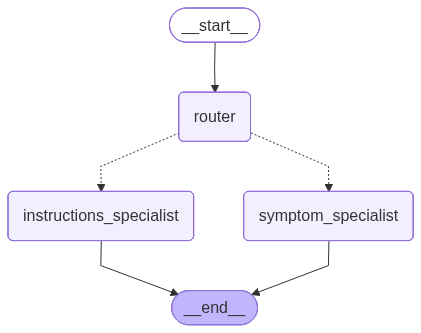

In [4]:
show_graph_structure(demo_graph)

## Sample questions

The examples below intentionally exercise both routes:

1. a symptom-focused question;
2. an instructions-focused question.

In [5]:
sample_questions = [
    'fever, sore throat, body aches for two days',
    'How should I describe my symptoms so this assistant can help me better?',
]

sample_results = [run_demo_question(demo_graph, question) for question in sample_questions]

Router response: destination='symptom_specialist' rationale='The user is describing symptoms that may require triage and further evaluation.'
Question: fever, sore throat, body aches for two days
Route: symptom_specialist
Answer:
<think>

</think>

Based on the symptoms, professional evaluation may be indicated.
The clinical indication points to: flu.
Disclaimer: This is not 100% precise and does not replace a professional medical diagnosis.
--------------------------------------------------------------------------------
Router response: destination='instructions_specialist' rationale='The user is asking for guidance on how to describe their symptoms effectively.'
Question: How should I describe my symptoms so this assistant can help me better?
Route: instructions_specialist
Answer:
To provide the best assistance, describe your symptoms with these key details:

1. **Age Range**: Mention if you're a child, teenager, adult, or elderly.
2. **Duration**: How long have you had these symptom

In [6]:
route_summary = [
    {
        "question": result["question"],
        "route": result["route"],
    }
    for result in sample_results
]

route_summary

[{'question': 'fever, sore throat, body aches for two days',
  'route': 'symptom_specialist'},
 {'question': 'How should I describe my symptoms so this assistant can help me better?',
  'route': 'instructions_specialist'}]